# Reto 4 – Integrador de resultados

**Objetivo:** Combinar los análisis de los compañeros y crear un resumen general del ecosistema.

Carga el conjunto de datos y explora las variables relevantes.

In [18]:
import pandas as pd

df = pd.read_csv("../data/resultados_experimentos.csv")
df.head()

,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


## Exploración inicial
Describe las columnas y analiza los tipos de datos.

In [19]:
print("Columnas del Reto 1:")
print(df1.columns)

print("\nColumnas del Reto 2:")
print(df2.columns)

print("\nColumnas del Reto 3:")
print(df3.columns)

print("\nInformación del Reto 1:")
df1.info()

print("\nInformación del Reto 2:")
df2.info()

print("\nInformación del Reto 3:")
df3.info()

Columnas del Reto 1:


NameError: name 'df1' is not defined

In [ ]:
df1["categoria_clima"].value_counts()

categoria_clima
húmedo templado    11
húmedo frío         9
Name: count, dtype: int64

In [ ]:
df2["categoria_luz"].value_counts()

categoria_luz
alta     7
baja     7
media    6
Name: count, dtype: int64

In [ ]:
df3["nivel_biomasa"].value_counts()

nivel_biomasa
alta     7
baja     7
media    6
Name: count, dtype: int64

## Desarrollo del reto
Aplica funciones y análisis según el objetivo. Usa `def` para definir tus funciones.

In [ ]:
df1.columns = df1.columns.str.strip().str.lower()
df2.columns = df2.columns.str.strip().str.lower()
df3.columns = df3.columns.str.strip().str.lower()

def integrar_datos(df1, df2, df3):
    df_integrado = df1.copy()

    df_reto2 = df2[["sitio", "indice_luz", "categoria_luz"]].copy()
    df_integrado = df_integrado.merge(df_reto2, on="sitio", how="left")

    df_reto3 = df3[["sitio", "nivel_biomasa"]].copy()
    df_integrado = df_integrado.merge(df_reto3, on="sitio", how="left")

    return df_integrado

df_integrado = integrar_datos(df1, df2, df3)

df_integrado.head()

,sitio,temperatura,humedad,luz,biomasa,categoria_clima,indice_luz,categoria_luz,nivel_biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8,húmedo templado,0.695007,alta,alta
1,Humedal Facatativá,18.0,89.7,395,225.8,húmedo frío,0.266532,baja,media
2,Río San Francisco,17.2,85.4,647,237.5,húmedo frío,0.436572,baja,media
3,Ladera de La Vega,21.7,81.4,769,252.4,húmedo templado,0.518893,baja,alta
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7,húmedo templado,0.899460,alta,alta


In [ ]:
print("Filas Reto 1:", len(df1))
print("Filas integrado:", len(df_integrado))

print("\nColumnas del resultado integrado:")
print(df_integrado.columns)

print("\nValores nulos:")
display(df_integrado.isnull().sum())

Filas Reto 1: 20
Filas integrado: 20

Columnas del resultado integrado:
Index(['sitio', 'temperatura', 'humedad', 'luz', 'biomasa', 'categoria_clima',
       'indice_luz', 'categoria_luz', 'nivel_biomasa'],
      dtype='object')

Valores nulos:


sitio              0
temperatura        0
humedad            0
luz                0
biomasa            0
categoria_clima    0
indice_luz         0
categoria_luz      0
nivel_biomasa      0
dtype: int64

In [ ]:
resumen_integrado = df_integrado.groupby(
    ["categoria_clima", "categoria_luz", "nivel_biomasa"]
).size().reset_index(name="numero_sitios")

resumen_integrado

,categoria_clima,categoria_luz,nivel_biomasa,numero_sitios
0,húmedo frío,alta,baja,1
1,húmedo frío,alta,media,1
2,húmedo frío,baja,baja,3
3,húmedo frío,baja,media,2
4,húmedo frío,media,alta,1
5,húmedo frío,media,media,1
6,húmedo templado,alta,alta,3
7,húmedo templado,alta,baja,2
8,húmedo templado,baja,alta,1
9,húmedo templado,baja,media,1


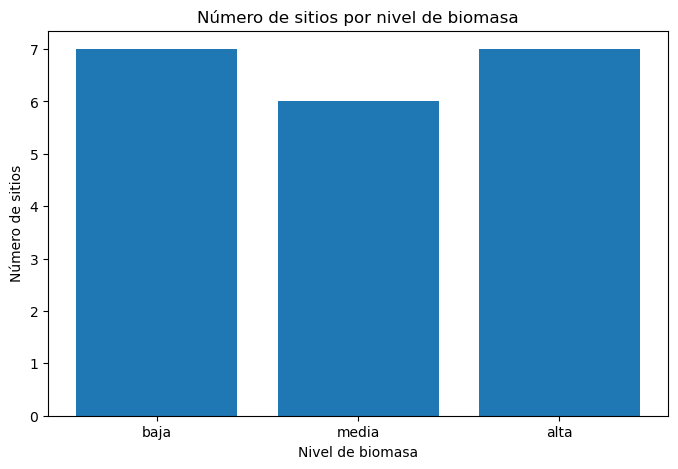

In [ ]:
conteo_biomasa = df_integrado.groupby("nivel_biomasa").size().reset_index(name="numero_sitios")

orden = ["baja", "media", "alta"]

conteo_biomasa["nivel_biomasa"] = pd.Categorical(
    conteo_biomasa["nivel_biomasa"],
    categories=orden,
    ordered=True
)

conteo_biomasa = conteo_biomasa.sort_values("nivel_biomasa")

plt.figure(figsize=(8, 5))
plt.bar(
    conteo_biomasa["nivel_biomasa"].astype(str),
    conteo_biomasa["numero_sitios"]
)

plt.title("Número de sitios por nivel de biomasa")
plt.xlabel("Nivel de biomasa")
plt.ylabel("Número de sitios")
plt.show()

In [ ]:
df_integrado.to_csv("../data/resultado_integrado.csv", index=False)

print("Archivo resultado_integrado.csv generado correctamente.")

Archivo resultado_integrado.csv generado correctamente.


## Interpretación de resultados
Escribe tus observaciones y conclusiones sobre los patrones encontrados.

# Parte Persona 5 – Reporte final y análisis integrado

En esta sección se realiza el análisis final del conjunto de datos integrado.  
Se calculan promedios generales, correlaciones entre variables, identificación de sitios extremos de biomasa y visualizaciones finales.

In [ ]:
import pandas as pd

df_integrado = pd.read_csv("../data/resultado_integrado.csv")

df_integrado.head()

,sitio,temperatura,humedad,luz,biomasa,categoria_clima,indice_luz,categoria_luz,nivel_biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8,húmedo templado,0.695007,alta,alta
1,Humedal Facatativá,18.0,89.7,395,225.8,húmedo frío,0.266532,baja,media
2,Río San Francisco,17.2,85.4,647,237.5,húmedo frío,0.436572,baja,media
3,Ladera de La Vega,21.7,81.4,769,252.4,húmedo templado,0.518893,baja,alta
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7,húmedo templado,0.899460,alta,alta


In [ ]:
def reporte_final(df):
    """
    Genera un reporte final del análisis ambiental.
    """

    # Promedios generales
    promedios_generales = df.select_dtypes(include="number").mean()

    # Sitio con mayor biomasa
    sitio_mayor_biomasa = df.loc[df["biomasa"].idxmax()]

    # Sitio con menor biomasa
    sitio_menor_biomasa = df.loc[df["biomasa"].idxmin()]

    # Correlaciones
    correlaciones = df.corr(numeric_only=True)["biomasa"].drop("biomasa")

    # Variable más relacionada con biomasa
    variable_mas_correlacionada = correlaciones.abs().idxmax()

    valor_correlacion = correlaciones[variable_mas_correlacionada]

    reporte = {
        "promedios_generales": promedios_generales,
        "sitio_mayor_biomasa": sitio_mayor_biomasa,
        "sitio_menor_biomasa": sitio_menor_biomasa,
        "variable_mas_correlacionada": variable_mas_correlacionada,
        "valor_correlacion": valor_correlacion
    }

    return reporte

In [ ]:
reporte = reporte_final(df_integrado)

In [ ]:
reporte["promedios_generales"]

temperatura     20.695000
humedad         78.090000
luz            901.000000
biomasa        196.415000
indice_luz       0.607962
dtype: float64

In [ ]:
reporte["sitio_mayor_biomasa"]

sitio               Humedal Cajicá
temperatura                   24.2
humedad                       75.2
luz                           1283
biomasa                      315.6
categoria_clima    húmedo templado
indice_luz                0.865722
categoria_luz                 alta
nivel_biomasa                 alta
Name: 11, dtype: object

In [ ]:
reporte["sitio_menor_biomasa"]

sitio              Bosque de Tenjo
temperatura                   19.6
humedad                       74.9
luz                            678
biomasa                       54.8
categoria_clima        húmedo frío
indice_luz                 0.45749
categoria_luz                 baja
nivel_biomasa                 baja
Name: 14, dtype: object

In [ ]:
print("Variable más correlacionada con biomasa:")
print(reporte["variable_mas_correlacionada"])

print("\nValor de correlación:")
print(reporte["valor_correlacion"])


Variable más correlacionada con biomasa:
temperatura

Valor de correlación:
0.3002519753994814


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

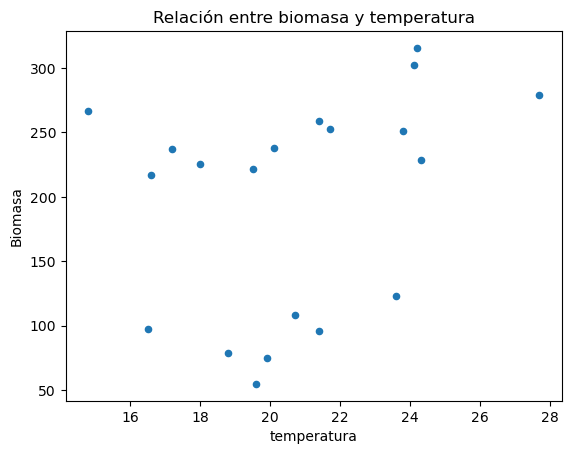

In [ ]:
variable = reporte["variable_mas_correlacionada"]

df_integrado.plot.scatter(
    x=variable,
    y="biomasa"
)

plt.title(f"Relación entre biomasa y {variable}")
plt.xlabel(variable)
plt.ylabel("Biomasa")
plt.show()

In [ ]:
correlaciones = df_integrado.corr(numeric_only=True)

correlaciones

,temperatura,humedad,luz,biomasa,indice_luz
temperatura,1.000000,-0.226328,0.356842,0.300252,0.356842
humedad,-0.226328,1.000000,0.233984,0.176244,0.233984
luz,0.356842,0.233984,1.000000,0.170077,1.000000
biomasa,0.300252,0.176244,0.170077,1.000000,0.170077
indice_luz,0.356842,0.233984,1.000000,0.170077,1.000000


In [ ]:
df_integrado.to_csv("../data/reporte_final.csv", index=False)

print("Archivo reporte_final.csv generado correctamente.")

Archivo reporte_final.csv generado correctamente.


# Conclusión final

En el análisis integrado se combinaron los resultados obtenidos en los retos de temperatura, humedad, luz y biomasa.

Primero se analizaron las variables ambientales y se clasificaron los sitios según sus condiciones climáticas y niveles de iluminación. Posteriormente, se clasificó la biomasa en niveles bajo, medio y alto para comparar las condiciones ambientales asociadas a cada grupo.

El análisis final permitió identificar los sitios con mayor y menor biomasa, así como calcular los promedios generales de las variables ambientales. Además, mediante el análisis de correlación se determinó cuál variable ambiental presenta la relación más fuerte con la biomasa.

Finalmente, el gráfico de dispersión permitió visualizar la relación entre la biomasa y la variable ambiental más influyente, facilitando la interpretación ecológica de los resultados experimentales.